In [52]:
import pandas as pd

portfolio = pd.read_csv('../../data/portfolio.csv')
profile = pd.read_csv('../../data/profile.csv')
transcript = pd.read_csv('../../data/transcript.csv')
menu = pd.read_csv('../../data/starbucks_menu_260112.csv')

In [50]:
# 전체 행 출력
pd.set_option('display.max_rows', None)

# 전체 열 출력
pd.set_option('display.max_columns', None)

# 전체 행 출력 해제(기본값 복원)
# pd.reset_option('display.max_rows')

In [ ]:
pd.set_option('display.max_colwidth', None)

In [13]:
transcript['time'].value_counts()

time
408    17030
576    17015
504    16822
336    16302
168    16150
       ...  
318      940
330      938
156      914
162      910
150      894
Name: count, Length: 120, dtype: int64

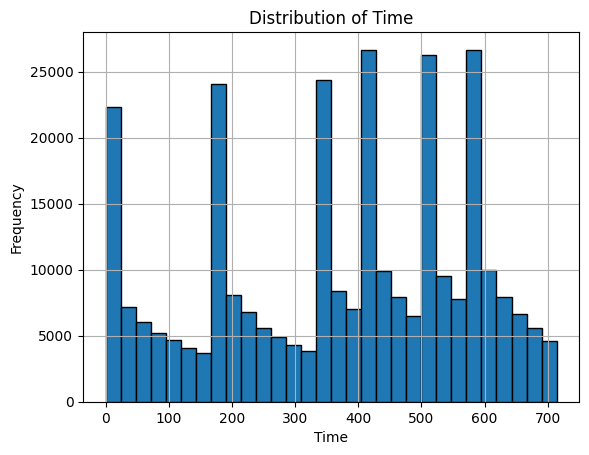

In [14]:
import matplotlib.pyplot as plt

# 히스토그램 그리기
transcript['time'].hist(bins=30, edgecolor='black')

# 제목과 라벨 추가
plt.title('Distribution of Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

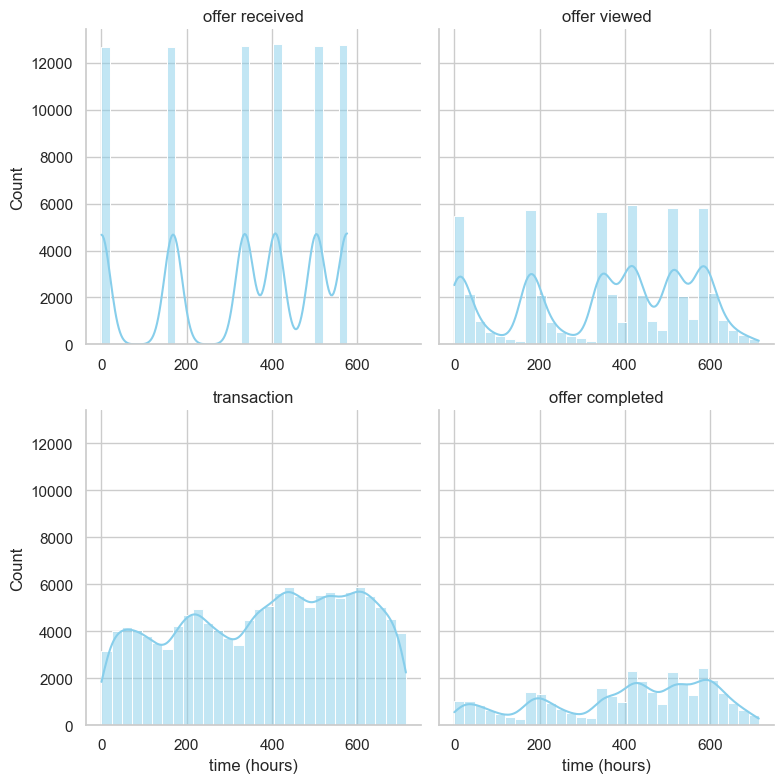

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# event 종류별로 서브플롯 생성
g = sns.FacetGrid(transcript_df, col="event", col_wrap=2, height=4, sharex=True)
g.map(sns.histplot, "time", bins=30, kde=True, color='skyblue')

g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(labelbottom=True)

# x축 이름(time)을 명확하게 추가
g.set_axis_labels("time (hours)", "Count") 
plt.tight_layout()
plt.show()

In [27]:
print(transcript_df.groupby('event')['time'].agg(['mean', 'median', 'count']))

                       mean  median   count
event                                      
offer completed  401.052801   432.0   33579
offer received   332.579519   408.0   76277
offer viewed     354.290515   408.0   57725
transaction      381.584334   402.0  138953


In [35]:
portfolio.head()

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [19]:
import ast

transcript_df = transcript.copy()

# 1. value → dict 변환
transcript_df['value_dict'] = transcript_df['value'].apply(ast.literal_eval)

# 2. value에서 값 추출
transcript_df['offer_id'] = transcript_df['value_dict'].apply(
    lambda x: x.get('offer id', x.get('offer_id'))
)
transcript_df['amount'] = transcript_df['value_dict'].apply(lambda x: x.get('amount'))
transcript_df['reward'] = transcript_df['value_dict'].apply(lambda x: x.get('reward'))

In [34]:
transcript_df[transcript_df['event'] == 'transaction'].head(10)

,Unnamed: 0,person,event,value,time,value_dict,offer_id,amount,reward
12654,12654,02c083884c7d45b39cc68e1314fec56c,transaction,{'amount': 0.8300000000000001},0,{'amount': 0.8300000000000001},NaN,0.83,NaN
12657,12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,{'amount': 34.56},0,{'amount': 34.56},NaN,34.56,NaN
12659,12659,54890f68699049c2a04d415abc25e717,transaction,{'amount': 13.23},0,{'amount': 13.23},NaN,13.23,NaN
12670,12670,b2f1cd155b864803ad8334cdf13c4bd2,transaction,{'amount': 19.51},0,{'amount': 19.51},NaN,19.51,NaN
12671,12671,fe97aa22dd3e48c8b143116a8403dd52,transaction,{'amount': 18.97},0,{'amount': 18.97},NaN,18.97,NaN
12678,12678,629fc02d56414d91bca360decdfa9288,transaction,{'amount': 33.9},0,{'amount': 33.9},NaN,33.90,NaN
12686,12686,bbeb54e861614fc7b22a8844f72dca6c,transaction,{'amount': 0.22},0,{'amount': 0.22},NaN,0.22,NaN
12687,12687,a97e6f33219c432db82acfa0d19c602d,transaction,{'amount': 18.59},0,{'amount': 18.59},NaN,18.59,NaN
12691,12691,676506bad68e4161b9bbaffeb039626b,transaction,{'amount': 18.01},0,{'amount': 18.01},NaN,18.01,NaN
12696,12696,8f7dd3b2afe14c078eb4f6e6fe4ba97d,transaction,{'amount': 19.11},0,{'amount': 19.11},NaN,19.11,NaN


In [ ]:
portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10 non-null     int64 
 1   reward      10 non-null     int64 
 2   channels    10 non-null     object
 3   difficulty  10 non-null     int64 
 4   duration    10 non-null     int64 
 5   offer_type  10 non-null     object
 6   id          10 non-null     object
dtypes: int64(4), object(3)
memory usage: 692.0+ bytes


In [5]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  object 
 2   age               17000 non-null  int64  
 3   id                17000 non-null  object 
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 797.0+ KB


In [6]:
transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  306534 non-null  int64 
 1   person      306534 non-null  object
 2   event       306534 non-null  object
 3   value       306534 non-null  object
 4   time        306534 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.7+ MB


In [10]:
portpolio.describe()

,Unnamed: 0,reward,difficulty,duration
count,10.00000,10.000000,10.000000,10.000000
mean,4.50000,4.200000,7.700000,6.500000
std,3.02765,3.583915,5.831905,2.321398
min,0.00000,0.000000,0.000000,3.000000
25%,2.25000,2.000000,5.000000,5.000000
50%,4.50000,4.000000,8.500000,7.000000
75%,6.75000,5.000000,10.000000,7.000000
max,9.00000,10.000000,20.000000,10.000000


In [11]:
profile.describe()

,Unnamed: 0,age,became_member_on,income
count,17000.000000,17000.000000,1.700000e+04,14825.000000
mean,8499.500000,62.531412,2.016703e+07,65404.991568
std,4907.621624,26.738580,1.167750e+04,21598.299410
min,0.000000,18.000000,2.013073e+07,30000.000000
25%,4249.750000,45.000000,2.016053e+07,49000.000000
50%,8499.500000,58.000000,2.017080e+07,64000.000000
75%,12749.250000,73.000000,2.017123e+07,80000.000000
max,16999.000000,118.000000,2.018073e+07,120000.000000


In [12]:
transcript.describe()

,Unnamed: 0,time
count,306534.000000,306534.000000
mean,153266.500000,366.382940
std,88488.888045,200.326314
min,0.000000,0.000000
25%,76633.250000,186.000000
50%,153266.500000,408.000000
75%,229899.750000,528.000000
max,306533.000000,714.000000


In [47]:
import pandas as pd
import ast

# 원본 복사
portfolio_df = portfolio.copy()
profile_df = profile.copy()
transcript_df = transcript.copy()

# 1. value → dict 변환
transcript_df['value_dict'] = transcript_df['value'].apply(ast.literal_eval)

# 2. value에서 값 추출
transcript_df['offer_id'] = transcript_df['value_dict'].apply(
    lambda x: x.get('offer id', x.get('offer_id'))
)
transcript_df['amount'] = transcript_df['value_dict'].apply(lambda x: x.get('amount'))
transcript_df['reward'] = transcript_df['value_dict'].apply(lambda x: x.get('reward'))

# customer_id로 통일
transcript_df = transcript_df.rename(columns={'person': 'customer_id'})
profile_df = profile_df.rename(columns={'id': 'customer_id'})
portfolio_df = portfolio_df.rename(columns={'id': 'offer_id'})

# 3. merge
merged_df = transcript_df.merge(
    profile_df,
    on='customer_id',
    how='left'
)

merged_df = merged_df.merge(
    portfolio_df,
    on='offer_id',
    how='left'
)

# 확인
# print(merged_df.head())
# print(merged_df.shape)
# print(merged_df.columns)

In [48]:
print(merged_df.shape)
print(merged_df.isna().sum())

(306534, 20)
Unnamed: 0_x             0
customer_id              0
event                    0
value                    0
time                     0
value_dict               0
offer_id            138953
amount              167581
reward_x            272955
Unnamed: 0_y            18
gender               33790
age                     18
became_member_on        18
income               33790
Unnamed: 0          138953
reward_y            138953
channels            138953
difficulty          138953
duration            138953
offer_type          138953
dtype: int64


In [83]:
print("transcript 고객 수:", transcript_df['customer_id'].nunique())
print("profile 고객 수:", profile_df['customer_id'].nunique())

missing_ids = set(transcript_df['customer_id']) - set(profile_df['customer_id'])
print("profile에 없는 고객 수:", len(missing_ids))

transcript 고객 수: 17000
profile 고객 수: 17000
profile에 없는 고객 수: 1


In [84]:
missing_ids = set(transcript_df['customer_id']) - set(profile_df['customer_id'])
print(missing_ids)

{'2.56564E+31'}


In [74]:
print(merged_df.loc[merged_df['age'].isna(), 'customer_id'])

54001     2.56564E+31
84294     2.56564E+31
103187    2.56564E+31
103188    2.56564E+31
111669    2.56564E+31
131372    2.56564E+31
131373    2.56564E+31
151460    2.56564E+31
197564    2.56564E+31
202405    2.56564E+31
238282    2.56564E+31
245952    2.56564E+31
259877    2.56564E+31
263670    2.56564E+31
263671    2.56564E+31
263672    2.56564E+31
275725    2.56564E+31
290546    2.56564E+31
Name: customer_id, dtype: object


In [75]:
profile_df[profile_df['customer_id'] == '2.56564E+31']

,Unnamed: 0,gender,age,customer_id,became_member_on,income


In [ ]:
profile_df[profile_df['customer_id'].astype(str).str.len() > 32]

,Unnamed: 0,gender,age,customer_id,became_member_on,income


In [79]:
profile_df['customer_id'].head(10)

0    68be06ca386d4c31939f3a4f0e3dd783
1    0610b486422d4921ae7d2bf64640c50b
2    38fe809add3b4fcf9315a9694bb96ff5
3    78afa995795e4d85b5d9ceeca43f5fef
4    a03223e636434f42ac4c3df47e8bac43
5    e2127556f4f64592b11af22de27a7932
6    8ec6ce2a7e7949b1bf142def7d0e0586
7    68617ca6246f4fbc85e91a2a49552598
8    389bc3fa690240e798340f5a15918d5c
9    8974fc5686fe429db53ddde067b88302
Name: customer_id, dtype: object

In [42]:
profile['gender'].unique()

<StringArray>
[nan, 'F', 'M', 'O']
Length: 4, dtype: str

In [49]:
# 1. offer received
offer_received = transcript_df[transcript_df['event'] == 'offer received'][
    ['customer_id', 'offer_id', 'time']
].rename(columns={'time': 'received_time'})

# 2. transaction
transactions = transcript_df[transcript_df['event'] == 'transaction'][
    ['customer_id', 'time', 'amount']
].rename(columns={'time': 'transaction_time'})

# 3. duration 붙이기
offer_received = offer_received.merge(
    portfolio_df[['offer_id', 'duration']],
    on='offer_id',
    how='left'
)

# 4. 고객 기준 merge
merged = offer_received.merge(
    transactions,
    on='customer_id',
    how='left'
)

# 5. 조건 필터
merged['valid'] = (
    (merged['transaction_time'] >= merged['received_time']) &
    (merged['transaction_time'] <= merged['received_time'] + merged['duration'])
)

# 6. 최종 연결
final = merged[merged['valid']]

In [50]:
final.head()

,customer_id,offer_id,received_time,duration,transaction_time,amount,valid
202,02c083884c7d45b39cc68e1314fec56c,ae264e3637204a6fb9bb56bc8210ddfd,0,7,0.0,0.83,True
203,02c083884c7d45b39cc68e1314fec56c,ae264e3637204a6fb9bb56bc8210ddfd,0,7,6.0,1.44,True
283,676506bad68e4161b9bbaffeb039626b,ae264e3637204a6fb9bb56bc8210ddfd,0,7,0.0,18.01,True
291,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,2906b810c7d4411798c6938adc9daaa5,0,7,0.0,34.56,True
864,ed46fca6de7042478b411690878dc069,2906b810c7d4411798c6938adc9daaa5,0,7,0.0,1.16,True


In [ ]:
import pandas as pd

# ----------------------------
# 0. 복사본
# ----------------------------
portfolio_df = portfolio.copy()
transcript_df = transcript.copy()

#  value → dict 변환
transcript_df['value_dict'] = transcript_df['value'].apply(ast.literal_eval)

#  value에서 값 추출
transcript_df['offer_id'] = transcript_df['value_dict'].apply(
    lambda x: x.get('offer id', x.get('offer_id'))
)
transcript_df['amount'] = transcript_df['value_dict'].apply(lambda x: x.get('amount'))
transcript_df['reward'] = transcript_df['value_dict'].apply(lambda x: x.get('reward'))


# customer_id 컬럼명 통일
if 'person' in transcript_df.columns:
    transcript_df = transcript_df.rename(columns={'person': 'customer_id'})

if 'id' in portfolio_df.columns:
    portfolio_df = portfolio_df.rename(columns={'id': 'offer_id'})

# ----------------------------
# 1. offer received 데이터 준비
# ----------------------------
offer_received = transcript_df[transcript_df['event'] == 'offer received'][
    ['customer_id', 'offer_id', 'time']
].copy()

offer_received = offer_received.rename(columns={'time': 'received_time'})

# 같은 고객이 같은 오퍼를 여러 번 받을 수 있으므로 순번 부여
offer_received['received_seq'] = (
    offer_received.groupby(['customer_id', 'offer_id']).cumcount() + 1
)

# duration 붙이기 (일 → 시간 변환용)
offer_received = offer_received.merge(
    portfolio_df[['offer_id', 'duration']],
    on='offer_id',
    how='left'
)

offer_received['offer_end_time'] = offer_received['received_time'] + offer_received['duration'] * 24

# ----------------------------
# 2. transaction 데이터 준비
# ----------------------------
transactions = transcript_df[transcript_df['event'] == 'transaction'][
    ['customer_id', 'time', 'amount']
].copy()

transactions = transactions.rename(columns={'time': 'transaction_time'})

# ----------------------------
# 3. 고객 기준으로 붙인 뒤,
#    오퍼 유효기간 내 transaction만 남기기
# ----------------------------
merged = offer_received.merge(
    transactions,
    on='customer_id',
    how='left'
)

valid_tx = merged[
    (merged['transaction_time'] >= merged['received_time']) &
    (merged['transaction_time'] <= merged['offer_end_time'])
].copy()

# ----------------------------
# 4. offer received별로 transaction 발생 여부 표시
# ----------------------------
# 하나의 offer received에 transaction이 1건 이상 있으면 conversion = 1
tx_flag = valid_tx.groupby(
    ['customer_id', 'offer_id', 'received_seq'],
    as_index=False
).agg(
    transaction_count=('transaction_time', 'count'),
    transaction_amount_sum=('amount', 'sum'),
    first_transaction_time=('transaction_time', 'min')
)

tx_flag['converted_to_transaction'] = 1

# offer_received 테이블에 결합
result = offer_received.merge(
    tx_flag[['customer_id', 'offer_id', 'received_seq', 'transaction_count',
             'transaction_amount_sum', 'first_transaction_time', 'converted_to_transaction']],
    on=['customer_id', 'offer_id', 'received_seq'],
    how='left'
)

# transaction 없는 경우 0 처리
result['converted_to_transaction'] = result['converted_to_transaction'].fillna(0).astype(int)
result['transaction_count'] = result['transaction_count'].fillna(0).astype(int)
result['transaction_amount_sum'] = result['transaction_amount_sum'].fillna(0)

# 최종 전환율 계산

total_received = len(result)
converted_received = result['converted_to_transaction'].sum()
conversion_rate = converted_received / total_received

print("전체 offer received 건수:", total_received)
print("transaction으로 이어진 건수:", converted_received)
print("offer received → transaction 전환율:", round(conversion_rate * 100, 2), "%")


전체 offer received 건수: 76277
transaction으로 이어진 건수: 59952
offer received → transaction 전환율: 78.6 %


전체 offer received 건수: 76277
transaction으로 이어진 건수: 59952
offer received → transaction 전환율: 78.6 %


고객 기준 전환율: 96.27 %


In [56]:
offer_received[offer_received['received_seq'] > 1]

,customer_id,offer_id,received_time,received_seq,duration,offer_end_time
12694,0861b9ca31b741bb8b411b18f82d18f6,f19421c1d4aa40978ebb69ca19b0e20d,168,2,5,288
12697,d3f146b615514c6380b168bb3df5f05b,f19421c1d4aa40978ebb69ca19b0e20d,168,2,5,288
12698,2e87ba0fba1a4d1a8614af771f07a94d,2298d6c36e964ae4a3e7e9706d1fb8c2,168,2,7,336
12702,8045834137dc47faa24f2c4547969f33,f19421c1d4aa40978ebb69ca19b0e20d,168,2,5,288
12718,b5abc1e85be84f43937b4fca0ad238cb,2298d6c36e964ae4a3e7e9706d1fb8c2,168,2,7,336
...,...,...,...,...,...,...
76263,392d23b2c958493197f647bedfe4f418,ae264e3637204a6fb9bb56bc8210ddfd,576,2,7,744
76266,76ddbd6576844afe811f1a3c0fbb5bec,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,2,7,744
76270,f924927e7f844ecebf87eef93f4d2688,5a8bc65990b245e5a138643cd4eb9837,576,2,3,648
76273,cb23b66c56f64b109d673d5e56574529,2906b810c7d4411798c6938adc9daaa5,576,2,7,744


In [55]:
result = result.merge(
    portfolio_df[['offer_id', 'offer_type']],
    on='offer_id',
    how='left'
)

offer_summary = result.groupby('offer_type', as_index=False).agg(
    received_count=('offer_id', 'count'),
    converted_count=('converted_to_transaction', 'sum')
)

offer_summary['conversion_rate'] = (
    offer_summary['converted_count'] / offer_summary['received_count']
)

print(offer_summary)

      offer_type  received_count  converted_count  conversion_rate
0           bogo           30499            24522         0.804026
1       discount           30543            25947         0.849524
2  informational           15235             9483         0.622448
